# AI Data-Quality Triage — a working demo

**The claim this notebook demonstrates:** *AI agents can take a raw data-quality alert and turn it into a complete, trustworthy incident diagnosis — automatically, in seconds, with humans involved only where risk demands it.*

The story: a small online shop (mugs, t-shirts, hoodies…). Something breaks in its sales data. Watch a team of small AI agents figure out **what** broke, **why**, **how much it matters**, and **what to do about it**.

What each part proves:

1. **Detection can stay dumb** — a simple threshold check fires the alert; a chart shows you the anomaly before any AI runs.
2. **The agents genuinely reason** — Act 2 reruns the *identical* agents on a different failure and gets a different, correct diagnosis.
3. **AI output can be trusted enough to act on** — Pydantic validates structure *and* meaning ("a confident root cause must cite evidence").
4. **Risk is governable** — P1 / high-risk / low-confidence outcomes route to a human; the rest may auto-apply.
5. **Waste is preventable** — a dedup gate short-circuits repeat alerts before any agent spends money.

| Layer | In this notebook | In production |
|---|---|---|
| Warehouse | in-memory SQLite | your real warehouse |
| Lineage + catalog | Python dicts | Glue / Collibra / dbt / OpenLineage via MCP |
| Detection | real checks (run here) | Great Expectations + ML drift |
| **AI agents** | **real** | **real (same code)** |
| **Pydantic validation** | **real** | **real** |
| **Orchestrator** | **real** | **real** |

> Runs out of the box in **MOCK mode** — no API key needed. Add an OpenAI or Anthropic key to a `.env` file to watch the agents reason live.
>
> *Honest boundary:* the enterprise plumbing is stubbed, so this demo confirms the **architecture**, not enterprise scale — and in production the diagnosis is only as good as your real lineage source.

## Setup

One install cell. `openai` / `anthropic` are only exercised in live mode — MOCK mode needs neither at runtime.

In [1]:
%pip install -q pydantic anthropic openai python-dotenv pandas matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## Pick a mode

MOCK is the default: the full pipeline runs instantly with canned (but Pydantic-validated) agent responses. To go live, put `OPENAI_API_KEY` or `ANTHROPIC_API_KEY` (and optionally `MODEL`) in a `.env` file next to this notebook's repo root. Anthropic wins if both are set. There is no silent fallback: live mode errors surface as errors.

In [2]:
import os
from dotenv import load_dotenv

load_dotenv()

if os.getenv("ANTHROPIC_API_KEY"):
    PROVIDER, MODEL = "anthropic", os.getenv("MODEL", "claude-sonnet-4-6")
elif os.getenv("OPENAI_API_KEY"):
    PROVIDER, MODEL = "openai", os.getenv("MODEL", "gpt-4o-mini")
else:
    PROVIDER, MODEL = "mock", None

print("MOCK mode — no LLM calls, canned responses" if PROVIDER == "mock"
      else f"LIVE mode — {PROVIDER} -> {MODEL}")

MOCK mode — no LLM calls, canned responses


---
## Part 1 — The shop (with a planted bug)

Five products, ~40 orders a day, 15 days. `seed_shop` plants one of two bugs on the **last day**:

- `price_glitch` — someone fat-fingers the Coffee Mug's price to **$120 instead of $12** (a `manual_price_update` change event at 08:00). The mug is the best-seller (~40% of orders), so average order value jumps ~3x.
- `volume_drop` — the `order_ingest` pipeline fails at 06:30 and ~80% of the day's orders never arrive.

Lineage is the backbone: `products → orders → daily_sales → {sales_dashboard, finance_report, demand_forecast}`. Here it's a dict; in production it's your lineage tool behind an MCP server — same contract either way.

In [3]:
import sqlite3, random
from datetime import date, timedelta

PRODUCTS = [
    # (sku, name, price, share of order volume)
    ("MUG-01", "Coffee Mug",   12.0, 0.40),
    ("TSH-02", "T-Shirt",      25.0, 0.20),
    ("NBK-03", "Notebook",      8.0, 0.15),
    ("BTL-04", "Water Bottle", 18.0, 0.15),
    ("HDY-05", "Hoodie",       40.0, 0.10),
]

def seed_shop(n_days=15, bug_type="price_glitch", magnitude=10.0, orders_per_day=40, seed=42):
    """In-memory shop warehouse with a bug planted on the last day.
    bug_type: "price_glitch" (magnitude = price multiplier) | "volume_drop" (magnitude = % of orders lost)
    """
    rng = random.Random(seed)
    base = date(2026, 7, 1)
    days = [base + timedelta(days=i) for i in range(n_days)]

    con = sqlite3.connect(":memory:")
    c = con.cursor()
    c.execute("CREATE TABLE products(sku TEXT, name TEXT, price REAL)")
    c.execute("CREATE TABLE orders(id INTEGER, date TEXT, sku TEXT, qty INTEGER, unit_price REAL, total REAL)")
    c.execute("CREATE TABLE daily_sales(date TEXT, total_sales REAL)")

    for sku, name, price, _ in PRODUCTS:
        c.execute("INSERT INTO products VALUES(?,?,?)", (sku, name, price))

    skus    = [p[0] for p in PRODUCTS]
    prices  = {p[0]: p[2] for p in PRODUCTS}
    weights = [p[3] for p in PRODUCTS]

    oid = 0
    for i, d in enumerate(days):
        is_bug_day = (i == n_days - 1)
        day_prices = dict(prices)
        if is_bug_day and bug_type == "price_glitch":
            day_prices["MUG-01"] = round(prices["MUG-01"] * magnitude, 2)
        n_orders = orders_per_day
        if is_bug_day and bug_type == "volume_drop":
            n_orders = max(1, int(orders_per_day * (1 - magnitude / 100)))
        for _ in range(n_orders):
            oid += 1
            sku = rng.choices(skus, weights=weights)[0]
            qty = rng.randint(1, 3)
            c.execute("INSERT INTO orders VALUES(?,?,?,?,?,?)",
                      (oid, d.isoformat(), sku, qty, day_prices[sku],
                       round(qty * day_prices[sku], 2)))

    for d in days:
        tot = c.execute("SELECT SUM(total) FROM orders WHERE date=?", (d.isoformat(),)).fetchone()[0] or 0.0
        c.execute("INSERT INTO daily_sales VALUES(?,?)", (d.isoformat(), round(tot, 2)))
    con.commit()

    LINEAGE = {
        "products":    {"upstream": [],                           "downstream": ["orders"]},
        "orders":      {"upstream": ["products", "order_ingest"], "downstream": ["daily_sales"]},
        "daily_sales": {"upstream": ["orders"],
                        "downstream": ["sales_dashboard", "finance_report", "demand_forecast"]},
    }
    CATALOG = {
        "orders":          {"criticality": "medium", "sensitivity": "financial"},
        "daily_sales":     {"criticality": "high",   "sensitivity": "financial"},
        "sales_dashboard": {"type": "dashboard",     "criticality": "high"},
        "finance_report":  {"type": "report",        "criticality": "regulatory"},
        "demand_forecast": {"type": "ml_feature",    "criticality": "medium"},
    }
    if bug_type == "price_glitch":
        CHANGES = [{"asset": "products",     "event": "manual_price_update", "at": f"{days[-1].isoformat()}T08:00Z"}]
    else:
        CHANGES = [{"asset": "order_ingest", "event": "pipeline_failure",    "at": f"{days[-1].isoformat()}T06:30Z"}]

    return con, c, days, LINEAGE, CATALOG, CHANGES

con, c, days, LINEAGE, CATALOG, CHANGES = seed_shop()
n_orders = c.execute("SELECT COUNT(*) FROM orders").fetchone()[0]
top_price = c.execute("SELECT MAX(unit_price) FROM orders WHERE date=?", (days[-1].isoformat(),)).fetchone()[0]
print(f"Seeded {len(days)} days, {n_orders} orders. Top unit price on the last day: ${top_price} (Coffee Mug normally $12)")

Seeded 15 days, 600 orders. Top unit price on the last day: $120.0 (Coffee Mug normally $12)


### See the anomaly before any AI runs

Detection shouldn't be the impressive part. Your eye finds the problem instantly — the detectors just automate that glance.

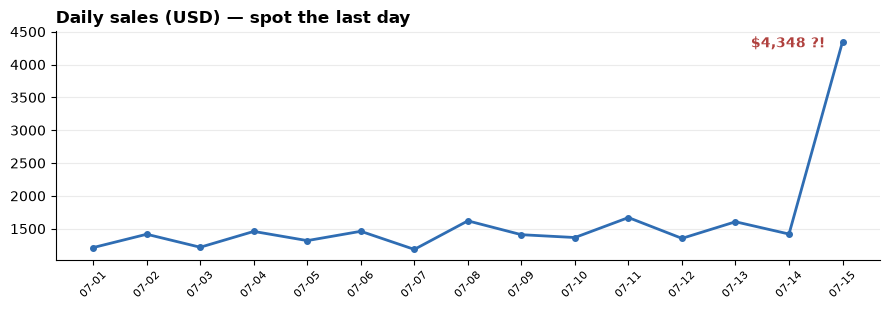

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_daily_sales(con, title="Daily sales (USD)"):
    df = pd.read_sql_query("SELECT date, total_sales FROM daily_sales ORDER BY date", con)
    fig, ax = plt.subplots(figsize=(9, 3.2))
    ax.plot(range(len(df)), df["total_sales"], color="#2f6db3", linewidth=2,
            marker="o", markersize=4)
    last_i, last_v = len(df) - 1, df["total_sales"].iloc[-1]
    ax.annotate(f"${last_v:,.0f} ?!", (last_i, last_v), textcoords="offset points",
                xytext=(-66, -4), fontweight="bold", color="#b0413e")
    ax.set_xticks(range(len(df)))
    ax.set_xticklabels([d[5:] for d in df["date"]], rotation=45, fontsize=8)
    ax.set_title(title, loc="left", fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()
    return df

_ = plot_daily_sales(con, "Daily sales (USD) — spot the last day")

---
## Part 2 — The MCP stub layer (how lineage is passed)

Agents never touch the lineage store directly. They see a **minimal, fixed tool contract** — asset name in, list of asset names out:

- `get_upstream(asset)` → `{"upstream": [...]}`
- `get_downstream(asset)` → `{"downstream": [...]}`
- `recent_changes(asset)` → `{"changes": [{"asset", "event", "at"}]}`
- `get_catalog(asset)` → `{tags}`
- `get_metrics(table, column)` → today-vs-baseline stats

**The contract is the standard; the backend is swappable.** Today these read a dict and SQLite. In production each is an MCP server that queries wherever lineage actually lives — AWS Glue, Collibra, dbt's manifest, or an OpenLineage event store — and *normalizes* the answer down to this same shape. The agents don't change; only the plumbing behind the tool does.

In [5]:
import statistics

def make_mcp(c, days, LINEAGE, CATALOG, CHANGES):
    """MCP stub layer. Swap each function for a real MCP server call in production."""
    def get_upstream(asset):   return {"upstream": LINEAGE.get(asset, {}).get("upstream", [])}
    def get_downstream(asset): return {"downstream": LINEAGE.get(asset, {}).get("downstream", [])}
    def recent_changes(asset): return {"changes": [x for x in CHANGES if x["asset"] == asset]}
    def get_catalog(asset):    return CATALOG.get(asset, {})

    def get_metrics(table, column):
        today = days[-1].isoformat()
        if column == "record_count":
            t_cnt = c.execute(f"SELECT COUNT(*) FROM {table} WHERE date=?", (today,)).fetchone()[0]
            per_day = [r[0] for r in c.execute(
                f"SELECT COUNT(*) FROM {table} WHERE date<? GROUP BY date", (today,)).fetchall()]
            return {"today_count": t_cnt,
                    "baseline_avg_count": round(statistics.mean(per_day), 1) if per_day else 0,
                    "drift_started": today}
        t = [r[0] for r in c.execute(f"SELECT {column} FROM {table} WHERE date=?", (today,)).fetchall() if r[0] is not None]
        h = [r[0] for r in c.execute(f"SELECT {column} FROM {table} WHERE date<?", (today,)).fetchall() if r[0] is not None]
        if not t or not h:
            return {"today_mean": 0, "baseline_mean": 0}
        return {"today_mean": round(statistics.mean(t), 2),
                "baseline_mean": round(statistics.mean(h), 2),
                "today_max": round(max(t), 2), "drift_started": today}

    return {"get_upstream": get_upstream, "get_downstream": get_downstream,
            "recent_changes": recent_changes, "get_catalog": get_catalog,
            "get_metrics": get_metrics}

mcp = make_mcp(c, days, LINEAGE, CATALOG, CHANGES)
print("MCP stubs ready:", sorted(mcp))

MCP stubs ready: ['get_catalog', 'get_downstream', 'get_metrics', 'get_upstream', 'recent_changes']


---
## Part 3 — Detection (dumb and fast, on purpose)

Two threshold checks. No AI here — the intelligence lives in triage. Each firing emits a **standardized issue event**: the one contract everything downstream consumes.

In [6]:
import json

def detect_issues(c, days):
    events = []
    today = days[-1].isoformat()

    # Check 1 — order-value drift (today's mean > 2x baseline mean)
    t = [r[0] for r in c.execute("SELECT total FROM orders WHERE date=?", (today,)).fetchall()]
    h = [r[0] for r in c.execute("SELECT total FROM orders WHERE date<?", (today,)).fetchall()]
    if t and h:
        ratio = statistics.mean(t) / statistics.mean(h)
        if ratio > 2.0:
            events.append({
                "issue_id": f"dq-{today}-0001",
                "asset": "orders", "column": "total",
                "signal": "distribution_drift",
                "observed": {"today_mean": round(statistics.mean(t), 2),
                             "baseline_mean": round(statistics.mean(h), 2),
                             "ratio": round(ratio, 2)},
                "detected_at": f"{today}T14:03:11Z",
            })

    # Check 2 — order volume drop (today's count < 0.5x per-day baseline)
    today_cnt = c.execute("SELECT COUNT(*) FROM orders WHERE date=?", (today,)).fetchone()[0]
    per_day = [r[0] for r in c.execute(
        "SELECT COUNT(*) FROM orders WHERE date<? GROUP BY date", (today,)).fetchall()]
    if per_day:
        avg = statistics.mean(per_day)
        if today_cnt < avg * 0.5:
            events.append({
                "issue_id": f"dq-{today}-0002",
                "asset": "orders", "column": "record_count",
                "signal": "volume_drop",
                "observed": {"today_count": today_cnt, "baseline_avg": round(avg, 1),
                             "ratio": round(today_cnt / avg, 2)},
                "detected_at": f"{today}T14:03:11Z",
            })
    return events

events = detect_issues(c, days)
print(f"{len(events)} issue(s) detected\n")
print(json.dumps(events[0], indent=2) if events else "No issues — try a bigger magnitude.")

1 issue(s) detected

{
  "issue_id": "dq-2026-07-15-0001",
  "asset": "orders",
  "column": "total",
  "signal": "distribution_drift",
  "observed": {
    "today_mean": 108.7,
    "baseline_mean": 35.2,
    "ratio": 3.09
  },
  "detected_at": "2026-07-15T14:03:11Z"
}


---
## Part 4 — Output contracts (Pydantic is the seatbelt)

Every agent must return JSON in an exact shape. Pydantic validates **types** and **meaning** — note the rule on `RootCause`: a confidence above 0.6 with no evidence is rejected outright. Bad output is caught before anything acts on it.

In [7]:
from typing import Literal
from pydantic import BaseModel, Field, model_validator

class Classification(BaseModel):
    issue_type: str
    reasoning: str
    needs_human: bool = False

class RootCause(BaseModel):
    top_cause: str
    confidence: float = Field(ge=0, le=1)
    evidence: list[str]
    needs_human: bool = False

    @model_validator(mode="after")
    def _evidence_required(self):
        if self.confidence > 0.6 and not self.evidence:
            raise ValueError("high confidence must cite evidence")
        return self

class Severity(BaseModel):
    priority: Literal["P1", "P2", "P3", "P4"]
    blast_radius: int
    rationale: str
    needs_human: bool = False

class RemediationPlan(BaseModel):
    playbook: str
    risk: Literal["low", "medium", "high"]
    summary: str
    needs_human: bool = False

print("contracts defined")

contracts defined


---
## Part 5 — The LLM client + self-healing validation

`ask_validated` is the loop that makes agents dependable: ask for JSON, validate with Pydantic, and on failure feed the error back and retry once. In MOCK mode the canned responses still pass through real Pydantic validation — the seatbelt is never off.

In [8]:
import time

def call_llm(system, user, max_tokens=900):
    if PROVIDER == "anthropic":
        from anthropic import Anthropic
        r = Anthropic().messages.create(model=MODEL, max_tokens=max_tokens,
                                        system=system, messages=[{"role": "user", "content": user}])
        return r.content[0].text
    if PROVIDER == "openai":
        from openai import OpenAI
        r = OpenAI().chat.completions.create(model=MODEL, max_tokens=max_tokens,
            messages=[{"role": "system", "content": system}, {"role": "user", "content": user}])
        return r.choices[0].message.content
    raise RuntimeError("call_llm should never be reached in MOCK mode")

def _strip_fences(s):
    s = s.strip()
    if s.startswith("```"):
        s = s.split("```", 2)[1]
        if s.lower().startswith("json"):
            s = s[4:]
        s = s.lstrip("\n")
        if "```" in s:
            s = s.rsplit("```", 1)[0]
    return s.strip()

MOCK_RESPONSES = {
    "distribution_drift": {
        "Classification": {"issue_type": "distribution_drift",
                           "reasoning": "today's average order value is ~3x baseline on a financial column",
                           "needs_human": False},
        "RootCause": {"top_cause": "manual price update set Coffee Mug (MUG-01) to $120 instead of $12",
                      "confidence": 0.9,
                      "evidence": ["products manual_price_update at 08:00 on the bug day",
                                   "order-value drift starts the same day",
                                   "only MUG-01 order totals are inflated (~10x)"],
                      "needs_human": False},
        "Severity": {"priority": "P1", "blast_radius": 3,
                     "rationale": "daily_sales feeds sales_dashboard, a regulatory finance_report, and the demand_forecast model",
                     "needs_human": False},
        "RemediationPlan": {"playbook": "correct_product_price_and_backfill", "risk": "medium",
                            "summary": "restore MUG-01 price to $12 and recompute the affected day's orders and daily_sales",
                            "needs_human": False},
    },
    "volume_drop": {
        "Classification": {"issue_type": "volume_drop",
                           "reasoning": "order count is ~80% below the daily baseline — looks like missing data, not a demand change",
                           "needs_human": False},
        "RootCause": {"top_cause": "order_ingest pipeline failure caused most of today's orders to never land",
                      "confidence": 0.85,
                      "evidence": ["order_ingest pipeline_failure at 06:30 on the bug day",
                                   "order count drops to ~20% of baseline the same day",
                                   "no price or product changes logged"],
                      "needs_human": False},
        "Severity": {"priority": "P1", "blast_radius": 3,
                     "rationale": "missing orders cascade to daily_sales, sales_dashboard, finance_report and demand_forecast",
                     "needs_human": False},
        "RemediationPlan": {"playbook": "rerun_order_ingest_and_backfill", "risk": "low",
                            "summary": "rerun the failed order_ingest pipeline for the affected date and recompute daily_sales",
                            "needs_human": False},
    },
}

def ask_validated(system, user, model_cls, signal, retries=1):
    if PROVIDER == "mock":
        return model_cls.model_validate(MOCK_RESPONSES[signal][model_cls.__name__])
    schema = json.dumps(model_cls.model_json_schema())
    prompt = "\n\n".join([user, "Return ONLY JSON matching this schema. No prose, no markdown fences:", schema])
    last = None
    for attempt in range(retries + 1):
        if attempt > 0:
            time.sleep(2)
            prompt = "\n\n".join([user, f"Previous answer failed validation: {last}",
                                  "Return ONLY valid JSON matching this schema:", schema])
        raw = _strip_fences(call_llm(system, prompt, max_tokens=900))
        try:
            return model_cls.model_validate_json(raw)
        except Exception as e:
            last = e
    raise RuntimeError(f"Validation failed after {retries + 1} attempts: {last}")

print(f"LLM client ready (mode: {PROVIDER})")

LLM client ready (mode: mock)


---
## Part 6 — The agents (division of labour)

Same lineage graph, opposite directions: **root-cause looks upstream** (what feeds the broken asset? what changed recently?), **severity looks downstream** (who consumes it? how critical are they?), the **classifier reads the asset itself**, and the **planner** waits for cause + severity because a fix needs both.

In [9]:
def classifier_agent(ev, mcp):
    ctx = {"signal": ev["signal"], "column_tags": mcp["get_catalog"](ev["asset"]),
           "observed": ev["observed"]}
    return ask_validated("You label data-quality issues by type.",
                         f"Classify this issue.\nContext: {json.dumps(ctx)}",
                         Classification, ev["signal"])

def root_cause_agent(ev, mcp):
    upstream = mcp["get_upstream"](ev["asset"])["upstream"]
    changes = []
    for asset in [ev["asset"]] + upstream:
        changes.extend(mcp["recent_changes"](asset)["changes"])
    ctx = {"upstream": upstream, "recent_changes": changes,
           "metrics": mcp["get_metrics"](ev["asset"], ev["column"])}
    return ask_validated(
        "You diagnose WHY data broke. Check upstream assets and recent changes. "
        "Cite specific evidence. If confidence < 0.5 set needs_human true.",
        f"Find the root cause.\nContext: {json.dumps(ctx, default=str)}",
        RootCause, ev["signal"])

def severity_agent(ev, mcp):
    downs = mcp["get_downstream"]("daily_sales")["downstream"]
    ctx = {"downstream": downs, "consumer_tags": {a: mcp["get_catalog"](a) for a in downs}}
    return ask_validated(
        "You score severity P1-P4 by downstream blast radius and consumer criticality. "
        "Regulatory and financial consumers raise the priority.",
        f"Score severity.\nContext: {json.dumps(ctx)}", Severity, ev["signal"])

def planner_agent(ev, rc, sev):
    ctx = {"signal": ev["signal"], "root_cause": rc.top_cause, "priority": sev.priority}
    return ask_validated(
        "You propose a remediation playbook name and rate its risk as low, medium, or high.",
        f"Propose a fix.\nContext: {json.dumps(ctx)}", RemediationPlan, ev["signal"])

print("agents ready")

agents ready


---
## Part 7 — The orchestrator (plain code, not an LLM)

Dedup gate first — a repeat alert stops **before** any agent spends money. Then the three independent agents (sequential here for a readable trace; parallel in production), then the chained planner, then one routing decision that aggregates every risk flag: P1, high-risk fix, low confidence, or any agent asking for a human.

In [10]:
def log(step, msg): print(f"  [{step:^10}] {msg}")

def triage(ev, mcp, open_cases):
    print("=" * 64)
    print("TRIAGE:", ev["issue_id"], "|", ev["asset"], "|", ev["signal"])
    print("=" * 64)

    sig = (ev["asset"], ev["signal"])
    if sig in open_cases:
        log("dedup", "duplicate -> attach to open case, STOP (no agent calls)")
        return {"routing": "deduped"}
    open_cases.add(sig)
    log("dedup", "new issue, proceeding")

    cls = classifier_agent(ev, mcp);   log("classify",   cls.issue_type)
    rc  = root_cause_agent(ev, mcp);   log("root-cause", f"{rc.top_cause} (conf {rc.confidence})")
    sev = severity_agent(ev, mcp);     log("severity",   f"{sev.priority}, blast_radius={sev.blast_radius}")
    plan = planner_agent(ev, rc, sev); log("plan",       f"{plan.playbook} (risk {plan.risk})")

    notes = []
    if sev.priority == "P1": notes.append("P1 severity")
    if plan.risk == "high":  notes.append("high-risk fix")
    if rc.confidence < 0.5:  notes.append("low confidence")
    if any(a.needs_human for a in (cls, rc, sev, plan)): notes.append("agent flagged")
    routing = "human" if notes else "auto"
    log("route", f"{routing.upper()} {notes}")

    return {"issue_id": ev["issue_id"], "classification": cls.model_dump(),
            "root_cause": rc.model_dump(), "severity": sev.model_dump(),
            "plan": plan.model_dump(), "routing": routing, "notes": notes}

print("orchestrator ready")

orchestrator ready


---
## Act 1 — Triage the price glitch

Detection already fired the event above. Now watch the full pipeline: gate → classify → root-cause → severity → plan → route. Note the verdict routes to a **human**: a P1 on a regulatory feed *should not* auto-fix — the gate working is the feature.

In [11]:
open_cases = set()
verdict = triage(events[0], mcp, open_cases)
print("\nFINAL VERDICT")
print(json.dumps(verdict, indent=2))

TRIAGE: dq-2026-07-15-0001 | orders | distribution_drift
  [  dedup   ] new issue, proceeding
  [ classify ] distribution_drift
  [root-cause] manual price update set Coffee Mug (MUG-01) to $120 instead of $12 (conf 0.9)
  [ severity ] P1, blast_radius=3
  [   plan   ] correct_product_price_and_backfill (risk medium)
  [  route   ] HUMAN ['P1 severity']

FINAL VERDICT
{
  "issue_id": "dq-2026-07-15-0001",
  "classification": {
    "issue_type": "distribution_drift",
    "reasoning": "today's average order value is ~3x baseline on a financial column",
    "needs_human": false
  },
  "root_cause": {
    "top_cause": "manual price update set Coffee Mug (MUG-01) to $120 instead of $12",
    "confidence": 0.9,
    "evidence": [
      "products manual_price_update at 08:00 on the bug day",
      "order-value drift starts the same day",
      "only MUG-01 order totals are inflated (~10x)"
    ],
    "needs_human": false
  },
  "severity": {
    "priority": "P1",
    "blast_radius": 3,
    "ra

### Same alert again — watch the dedup gate

The second run stops at the gate: no agent calls, no cost.

In [12]:
_ = triage(events[0], mcp, open_cases)

TRIAGE: dq-2026-07-15-0001 | orders | distribution_drift
  [  dedup   ] duplicate -> attach to open case, STOP (no agent calls)


---
## Act 2 — A different failure, the identical agents

Now the proof of generality. Reseed the shop with a **different** bug — the `order_ingest` pipeline fails and 80% of the day's orders never arrive. **Not one line of agent code changes.** Different evidence goes in (a pipeline failure upstream, a volume metric down 80%), a different diagnosis comes out.

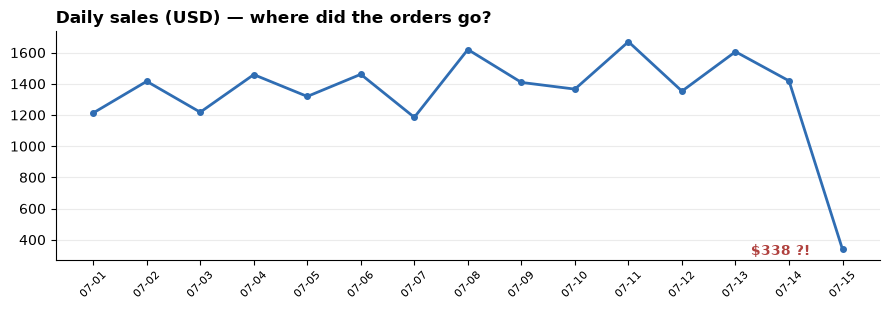

{
  "issue_id": "dq-2026-07-15-0002",
  "asset": "orders",
  "column": "record_count",
  "signal": "volume_drop",
  "observed": {
    "today_count": 7,
    "baseline_avg": 40,
    "ratio": 0.17
  },
  "detected_at": "2026-07-15T14:03:11Z"
} 

TRIAGE: dq-2026-07-15-0002 | orders | volume_drop
  [  dedup   ] new issue, proceeding
  [ classify ] volume_drop
  [root-cause] order_ingest pipeline failure caused most of today's orders to never land (conf 0.85)
  [ severity ] P1, blast_radius=3
  [   plan   ] rerun_order_ingest_and_backfill (risk low)
  [  route   ] HUMAN ['P1 severity']


In [13]:
con2, c2, days2, LINEAGE2, CATALOG2, CHANGES2 = seed_shop(bug_type="volume_drop", magnitude=80)
mcp2 = make_mcp(c2, days2, LINEAGE2, CATALOG2, CHANGES2)
_ = plot_daily_sales(con2, "Daily sales (USD) — where did the orders go?")

events2 = detect_issues(c2, days2)
print(json.dumps(events2[0], indent=2), "\n")
verdict2 = triage(events2[0], mcp2, set())

---
## What's real, what's stubbed, where this goes

**Real:** detection, the four agents, the MCP-style tool contracts, Pydantic validation with the retry loop, the orchestrator and its routing policy.

**Stubbed (and designed to be swapped):**
- `LINEAGE` / `CATALOG` dicts → a `lineage-mcp` / `catalog-mcp` over Glue, Collibra, dbt, or OpenLineage
- the SQLite shop → your warehouse behind a `metrics-mcp`
- the planted bugs → real detector output

**What this demo does *not* prove:** enterprise scale, or resilience to incomplete lineage. In production the diagnosis is only as good as the lineage you feed it — that's a data investment, not an AI problem.

**Next steps in this repo:** the same pipeline powers an interactive Streamlit app — `streamlit run dq/app.py` — with sliders for scenario and magnitude. From there: persist cases to a real store, wire one real MCP server, and only then consider gated auto-fix.

*The one-liner: the enterprise plumbing is stubbed; the AI brain is real. Point the stubs at real MCP servers and this ships.*